In [ ]:
# --- Run once: install (local vs Colab) ---
import subprocess
import sys


def _pip_install(args: list[str]) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


# Colab: install from GitHub.
COLAB_INSTALL_URL = "git+https://github.com/com3dian/FIND_Delft_Assignment.git@main"

try:
    import google.colab  # type: ignore  # noqa: F401
except ImportError:
    _pip_install(["-e", ".."])
else:
    _pip_install([COLAB_INSTALL_URL])

In [2]:
from diffusers import DDIMScheduler
from find_delft_assignment.model.pretrained import load_pretrained_ddpm

bundle = load_pretrained_ddpm()
ddpm_scheduler = bundle.ddpm_scheduler

ddpm_scheduler.set_timesteps(1000)

/home/com3dian/Github/FIND_Delft_Assignment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 51.20it/s]


In [3]:
from diffusers import DDIMScheduler

ddim_scheduler = DDIMScheduler.from_config(ddpm_scheduler.config)
ddim_scheduler.set_timesteps(45)
ddim_scheduler.timesteps

tensor([968, 946, 924, 902, 880, 858, 836, 814, 792, 770, 748, 726, 704, 682,
        660, 638, 616, 594, 572, 550, 528, 506, 484, 462, 440, 418, 396, 374,
        352, 330, 308, 286, 264, 242, 220, 198, 176, 154, 132, 110,  88,  66,
         44,  22,   0])

In [4]:
import torch
stride = 1000 // 45  # 1000 // 45 == 22
timesteps = torch.arange(45 - 1, -1, -1) * stride
timesteps


tensor([968, 946, 924, 902, 880, 858, 836, 814, 792, 770, 748, 726, 704, 682,
        660, 638, 616, 594, 572, 550, 528, 506, 484, 462, 440, 418, 396, 374,
        352, 330, 308, 286, 264, 242, 220, 198, 176, 154, 132, 110,  88,  66,
         44,  22,   0])

## DDIM: diffusers vs `DDIMSchedulerAdapter`

Same UNet, same noise schedule (`bundle.ddpm_scheduler`), `\u03b7=0` (deterministic). **One step:** first scheduler update from identical $x_t$ and $\epsilon_\theta$. **Full trajectory:** full 45-step DDIM from the same initial Gaussian noise.

One-step max |diff|: 0.000e+00


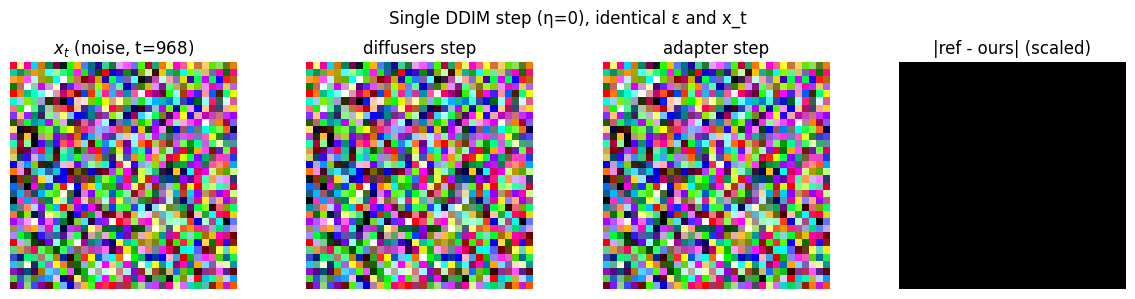

Full 45-step max |diff|: 0.000e+00


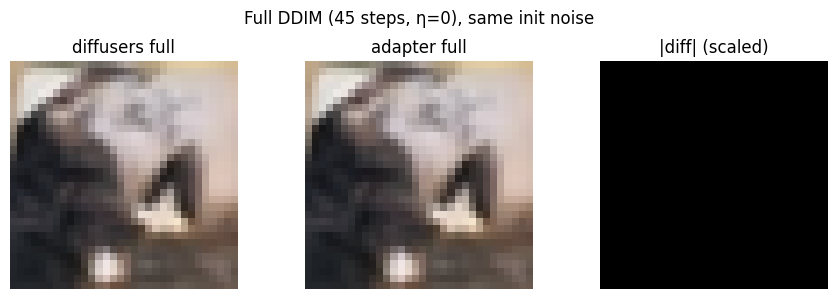

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import DDIMScheduler

from find_delft_assignment.sampling.common import unet_predict_noise
from find_delft_assignment.sampling.scheduler import DDIMSchedulerAdapter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = bundle.unet.to(device)
unet.eval()
dtype = next(unet.parameters()).dtype

# Match adapter: no x0 clipping in the scheduler step (adapter does not clip).
ddim_ref = DDIMScheduler.from_config(ddpm_scheduler.config, clip_sample=False)
adapter = DDIMSchedulerAdapter(ddpm_scheduler)

NUM_STEPS = 45
ddim_ref.set_timesteps(NUM_STEPS, device=device)
adapter.set_timesteps(NUM_STEPS, device=device)
assert torch.equal(ddim_ref.timesteps, adapter.timesteps)


def _to_display(x: torch.Tensor) -> np.ndarray:
    """[1,3,H,W] in model space -> RGB uint8 for imshow."""
    t = x[0].detach().float().cpu().clamp(-1.0, 1.0)
    t = (t + 1.0) * 0.5
    t = t.permute(1, 2, 0).numpy()
    return (t * 255.0).round().astype(np.uint8)


def _same_init_noise() -> torch.Tensor:
    g = torch.Generator(device=device).manual_seed(42)
    return torch.randn(1, 3, bundle.image_size, bundle.image_size, generator=g, device=device, dtype=dtype)


# ----- One step (first DDIM update) -----
x0 = _same_init_noise()
x_ref = x0.clone()
x_ours = x0.clone()
t0 = int(ddim_ref.timesteps[0].item())
with torch.inference_mode():
    eps = unet_predict_noise(unet, x_ref, t0)
    out_ref = ddim_ref.step(eps, t0, x_ref, eta=0.0)
    out_ours = adapter.step(eps, t0, x_ours, eta=0.0)

d1 = (out_ref.prev_sample - out_ours.prev_sample).abs().max().item()
print(f"One-step max |diff|: {d1:.3e}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(_to_display(x0))
axes[0].set_title(r"$x_t$ (noise, t=968)")
axes[1].imshow(_to_display(out_ref.prev_sample))
axes[1].set_title("diffusers step")
axes[2].imshow(_to_display(out_ours.prev_sample))
axes[2].set_title("adapter step")
diff = (out_ref.prev_sample - out_ours.prev_sample).abs().sum(dim=1, keepdim=True).repeat(1, 3, 1, 1)
axes[3].imshow(_to_display(diff / (diff.max() + 1e-8) * 2.0 - 1.0))
axes[3].set_title("|ref - ours| (scaled)")
for ax in axes:
    ax.axis("off")
plt.suptitle("Single DDIM step (\u03b7=0), identical \u03b5 and x_t")
plt.tight_layout()
plt.show()


# ----- Full trajectory -----
def full_ddim(step_fn: str, x_init: torch.Tensor) -> torch.Tensor:
    x = x_init.clone()
    with torch.inference_mode():
        for t in ddim_ref.timesteps:
            ti = int(t.item())
            eps = unet_predict_noise(unet, x, ti)
            if step_fn == "ref":
                x = ddim_ref.step(eps, ti, x, eta=0.0).prev_sample
            else:
                x = adapter.step(eps, ti, x, eta=0.0).prev_sample
    return x


x_init_full = _same_init_noise()
img_ref = full_ddim("ref", x_init_full)
img_ours = full_ddim("ours", x_init_full)
d_full = (img_ref - img_ours).abs().max().item()
print(f"Full {NUM_STEPS}-step max |diff|: {d_full:.3e}")

fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3))
axes2[0].imshow(_to_display(img_ref))
axes2[0].set_title("diffusers full")
axes2[1].imshow(_to_display(img_ours))
axes2[1].set_title("adapter full")
df = (img_ref - img_ours).abs().sum(dim=1, keepdim=True).repeat(1, 3, 1, 1)
axes2[2].imshow(_to_display(df / (df.max() + 1e-8) * 2.0 - 1.0))
axes2[2].set_title("|diff| (scaled)")
for ax in axes2:
    ax.axis("off")
plt.suptitle(f"Full DDIM ({NUM_STEPS} steps, \u03b7=0), same init noise")
plt.tight_layout()
plt.show()